# SVM: reproducción y adaptación del método del artículo (7.3)

El método de Xu & Cheng es un SVM para clasificar solicitantes de crédito en
riesgo bueno/malo sobre el German Credit Dataset, con dos variantes: kernel RBF
(gaussiano), que captura relaciones no lineales, y kernel lineal, cuyos
coeficientes se interpretan como la importancia de cada variable. Según
resumimos en la Primera entrega, los autores reportan que el SVM alcanza una
**accuracy de 75% frente a 70% de la regresión logística**, y que las variables
más importantes son el **saldo de la cuenta, la duración del crédito, el estado
de pago del crédito anterior, el propósito y el monto**. En este notebook:

1. **Reproducimos** el método sobre el German Credit Dataset, primero con la
   configuración del artículo (para contrastar el 75% frente a 70%) y luego con
   la configuración adaptada que usaremos en la base colombiana.
2. **Lo adaptamos** a la base simulada colombiana: SVM lineal y SVM RBF dentro
   del `Pipeline` sin fuga del notebook 03, con `C` y `γ` ajustados por
   validación cruzada.
3. **Comprobamos si el kernel gaussiano es el mejor**, comparándolo con los
   kernels lineal, polinómico y sigmoide.
4. Analizamos las **curvas de validación** de `C` y `γ` y las **fronteras de
   decisión** en 2D.
5. Contrastamos los **coeficientes del SVM lineal** con las variables que el
   artículo identifica como más importantes y con los pesos reales con que se
   generaron los datos.
6. Justificamos **qué se respetó y qué se cambió** en la adaptación.

Todas las decisiones (hiperparámetros, umbral) se toman con validación cruzada
dentro de train; el conjunto de test se usa una sola vez, al final, para
reportar.

In [1]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score, train_test_split,
    validation_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, confusion_matrix
from scipy.stats import spearmanr

sys.path.append("../src")
from preprocesamiento import SEED, NUM_COLS, CAT_COLS, cargar_particion, construir_pipeline
from generar_datos_simulados import generar_base, PESOS_CATEGORICOS
from evaluacion import costo_medio, umbral_costo_minimo, p_valor_corregido

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Las funciones de evaluación (costo 5:1, umbral de costo mínimo y prueba t
corregida) están en `src/evaluacion.py`, compartidas con el notebook 05. Como
el SVM no produce probabilidades de forma nativa,
evaluamos con su `decision_function` (la distancia firmada al hiperplano): el
ROC-AUC solo necesita que los puntajes ordenen bien a los clientes. El umbral
de decisión se elige minimizando el costo esperado con la matriz 5:1 sobre
predicciones de validación cruzada en train, y luego se aplica tal cual a test.

In [2]:
def metricas(y_true, puntajes, umbral):
    """Métricas de la clase "malo" con el umbral dado sobre el puntaje."""
    y_pred = (puntajes >= umbral).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_true, puntajes),
        "Recall (malo)": recall_score(y_true, y_pred),
        "Precisión (malo)": precision_score(y_true, y_pred, zero_division=0),
        "F1 (malo)": f1_score(y_true, y_pred),
        "Costo medio (5:1)": costo_medio(y_true, y_pred),
    }

## Parte A. Reproducción sobre el German Credit Dataset

Antes de adaptar el método, lo reproducimos en su escenario original: 1.000
solicitantes y 20 atributos (7 numéricos y 13 categóricos). El preprocesamiento
es el mínimo que exige un SVM: escalar las numéricas y codificar las
categóricas con one-hot, dentro de un `Pipeline`. Usamos una partición
estratificada 80/20 y ajustamos los hiperparámetros con validación cruzada de 5
folds sobre el 80% de entrenamiento. Lo hacemos en dos configuraciones:

- **A.1 Configuración del artículo:** SVM RBF, SVM lineal y regresión logística
  sin ponderar las clases, con hiperparámetros elegidos por accuracy y umbral
  estándar, para comparar directamente con el 75% frente a 70% reportado.
- **A.2 Configuración adaptada:** la que usaremos en la base colombiana, con
  `class_weight="balanced"`, hiperparámetros elegidos por ROC-AUC y umbral de
  costo mínimo según la matriz 5:1 del dataset (un falso negativo cuesta 5 veces
  más que un falso positivo).

### A.1 Configuración del artículo

In [3]:
cols_original = [
    "checking", "duration", "credit_history", "purpose", "credit_amount", "savings",
    "employment_since", "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age", "other_installment_plans", "housing",
    "existing_credits", "job", "num_dependents", "telephone", "foreign_worker", "target",
]
orig = pd.read_csv("../data/original/german.data", sep=" ", header=None, names=cols_original)
num_de = ["duration", "credit_amount", "installment_rate", "residence_since",
          "age", "existing_credits", "num_dependents"]
cat_de = [c for c in cols_original[:-1] if c not in num_de]

X_de = orig.drop(columns="target")
y_de = (orig["target"] == 2).astype(int)          # 1 = malo
Xde_tr, Xde_te, yde_tr, yde_te = train_test_split(
    X_de, y_de, test_size=0.20, stratify=y_de, random_state=SEED)

def pipeline_german(modelo):
    prep = ColumnTransformer([
        ("num", StandardScaler(), num_de),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_de),
    ], verbose_feature_names_out=False)
    return Pipeline([("prep", prep), ("modelo", modelo)])


# A.1 Configuración del artículo: sin pesos de clase, selección por accuracy, umbral estándar
config_articulo = {
    "SVM RBF": (SVC(kernel="rbf"), {"modelo__C": [0.3, 1, 3, 10, 30],
                                    "modelo__gamma": [0.001, 0.003, 0.01, 0.03, 0.1]}),
    "SVM lineal": (SVC(kernel="linear"), {"modelo__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1]}),
    "Regresión logística": (LogisticRegression(max_iter=2000),
                            {"modelo__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}),
}
filas, folds_acc = {}, {}
for nombre, (modelo, malla) in config_articulo.items():
    g = GridSearchCV(pipeline_german(modelo), malla, cv=cv, scoring="accuracy", n_jobs=-1).fit(Xde_tr, yde_tr)
    folds_acc[nombre] = np.array([g.cv_results_[f"split{k}_test_score"][g.best_index_] for k in range(5)])
    filas[nombre] = {"Accuracy CV (media)": folds_acc[nombre].mean(),
                     "Accuracy CV (desv.)": folds_acc[nombre].std(ddof=1),
                     "Accuracy test": g.score(Xde_te, yde_te),
                     "Mejores hiperparámetros": ", ".join(f"{k.replace('modelo__', '')}={float(v):g}"
                                                          for k, v in g.best_params_.items())}
reproduccion_articulo = pd.DataFrame(filas).T
reproduccion_articulo["Accuracy reportada (artículo)"] = [0.75, np.nan, 0.70]
p_svm_lr = p_valor_corregido(folds_acc["SVM RBF"], folds_acc["Regresión logística"], len(Xde_tr), k=5)
print("Referencia: accuracy de predecir siempre 'bueno' =", round(1 - yde_te.mean(), 3))
print(f"SVM RBF vs. regresión logística (accuracy CV): diferencia = "
      f"{folds_acc['SVM RBF'].mean() - folds_acc['Regresión logística'].mean():+.3f}, "
      f"p-valor corregido = {p_svm_lr:.2f}")
reproduccion_articulo

Referencia: accuracy de predecir siempre 'bueno' = 0.7
SVM RBF vs. regresión logística (accuracy CV): diferencia = +0.008, p-valor corregido = 0.76


,Accuracy CV (media),Accuracy CV (desv.),Accuracy test,Mejores hiperparámetros,Accuracy reportada (artículo)
SVM RBF,0.755,0.02774,0.77,"C=3, gamma=0.1",0.75
SVM lineal,0.7475,0.029843,0.785,C=0.1,NaN
Regresión logística,0.7475,0.042528,0.79,C=0.1,0.70


**Lectura: ¿reproducimos el 75% frente a 70% del artículo?**

- **El resultado del SVM sí se reproduce.** Nuestro SVM RBF alcanza una
  accuracy de 75.5% ± 2.8% en validación cruzada (77.0% en test), prácticamente
  igual al 75% que reportan los autores.
- **La brecha frente a la regresión logística no se reproduce.** Una regresión
  logística con las mismas variables escaladas y regularización ajustada por
  validación cruzada llega a 74.8%, no a 70%. La diferencia con el SVM RBF (+0.8
  puntos) no es estadísticamente significativa (p = 0.76 con la prueba t
  corregida).

Llama la atención que el 70% reportado para la regresión logística coincide
exactamente con la accuracy de predecir siempre "bueno" en este dataset. Una
explicación plausible es que la logística del artículo no se preparó igual que
el SVM (sin escalar o sin ajustar la regularización), aunque el artículo no da
detalles suficientes para confirmarlo. En accuracy de test, la logística (79.0%)
incluso supera al SVM RBF (77.0%), pero con solo 200 clientes de test esa
diferencia es ruido: la validación cruzada, que promedia 5 particiones, es la
comparación más confiable. **Conclusión:** reproducimos el desempeño del SVM,
pero en nuestra reproducción su ventaja sobre la regresión logística
desaparece cuando ambos modelos se preparan en igualdad de condiciones.

### A.2 Configuración adaptada

Con la configuración que usaremos en la base colombiana (pesos de clase,
selección por ROC-AUC y umbral de costo mínimo), el objetivo ya no es maximizar
la accuracy sino ordenar bien a los clientes y minimizar el costo de los
errores.

In [4]:
grid_de_lineal = GridSearchCV(
    pipeline_german(LinearSVC(class_weight="balanced", max_iter=50_000, random_state=SEED)),
    {"modelo__C": np.logspace(-3, 1, 9)}, cv=cv, scoring="roc_auc", n_jobs=-1,
).fit(Xde_tr, yde_tr)

grid_de_rbf = GridSearchCV(
    pipeline_german(SVC(kernel="rbf", class_weight="balanced")),
    {"modelo__C": [0.1, 0.3, 1, 3, 10, 30], "modelo__gamma": [0.001, 0.003, 0.01, 0.03, 0.1]},
    cv=cv, scoring="roc_auc", n_jobs=-1,
).fit(Xde_tr, yde_tr)

filas = {}
for nombre, g in [("SVM lineal", grid_de_lineal), ("SVM RBF", grid_de_rbf)]:
    punt_cv = cross_val_predict(g.best_estimator_, Xde_tr, yde_tr, cv=cv, method="decision_function")
    umbral = umbral_costo_minimo(yde_tr.to_numpy(), punt_cv)
    punt_te = g.best_estimator_.decision_function(Xde_te)
    m = metricas(yde_te.to_numpy(), punt_te, umbral)
    m.update({"ROC-AUC CV (media)": g.best_score_,
              "ROC-AUC CV (desv.)": g.cv_results_["std_test_score"][g.best_index_],
              "Accuracy": ((punt_te >= umbral).astype(int) == yde_te).mean(),
              "Accuracy (umbral 0)": ((punt_te >= 0).astype(int) == yde_te).mean(),
              "Mejores hiperparámetros": ", ".join(f"{k.replace('modelo__', '')}={float(v):g}"
                                                   for k, v in g.best_params_.items())})
    filas[nombre] = m
resultados_german = pd.DataFrame(filas).T
resultados_german

,ROC-AUC,Recall (malo),Precisión (malo),F1 (malo),Costo medio (5:1),ROC-AUC CV (media),ROC-AUC CV (desv.),Accuracy,Accuracy (umbral 0),Mejores hiperparámetros
SVM lineal,0.808333,0.883333,0.424,0.572973,0.535,0.783408,0.047184,0.605,0.72,C=0.00316228
SVM RBF,0.814643,0.883333,0.410853,0.560847,0.555,0.790179,0.040154,0.585,0.69,"C=0.3, gamma=0.03"


**Lectura.** Con la configuración adaptada, ambos SVM discriminan bien en test
(ROC-AUC de 0.808 el lineal y 0.815 el RBF), con valores de validación cruzada
algo menores y bastante variables entre folds (0.783 ± 0.047 y 0.790 ± 0.040):
con solo 800 registros de entrenamiento, cada fold de validación tiene unos 160
clientes y la estimación es ruidosa.

La accuracy con umbral 0 (0.72 y 0.69) es menor que en la configuración del
artículo porque `class_weight="balanced"` desplaza la frontera hacia la clase
"malo". Con el umbral de costo mínimo baja aún más (~0.60), y eso es lo
correcto: con un falso negativo cinco veces más caro, conviene rechazar a más
solicitantes dudosos. Así, el recall de "malo" sube a 0.88 y el costo medio
queda en 0.54 por cliente, frente a 1.50 que costaría aprobar a todos (el 30% de
"malos" por un costo de 5). Este contraste entre A.1 y A.2 muestra por qué la
accuracy no es la métrica adecuada para este problema, como ya planteamos en la
Primera entrega: el modelo con mejor accuracy no es el que menos cuesta.

## Parte B. Adaptación a la base simulada colombiana

Ahora aplicamos el mismo método a la base de trabajo
(`credito_simulado_con_faltantes.csv`), con la partición y el `Pipeline` del
notebook 03: imputación (saldo por categoría, mediana y moda), escalamiento y
one-hot, todo ajustado solo con train. El desbalance se trata con
`class_weight="balanced"`, la estrategia que ganó en la validación cruzada del
notebook 03.

In [5]:
X_train, X_test, y_train_txt, y_test_txt = cargar_particion()
y_train = (y_train_txt == "malo").astype(int).to_numpy()
y_test = (y_test_txt == "malo").astype(int).to_numpy()
print("Train:", X_train.shape, "| Test:", X_test.shape,
      "| % malo train/test:", round(y_train.mean(), 4), round(y_test.mean(), 4))

Train: (5200, 11) | Test: (1300, 11) | % malo train/test: 0.2246 0.2246


### B.1 SVM lineal: ajuste de `C`

`C` controla el equilibrio entre un margen amplio y los errores de
clasificación en train: un `C` pequeño tolera más errores y da un modelo más
regularizado; un `C` grande intenta clasificar bien cada punto y puede
sobreajustar. Exploramos `C` en escala logarítmica entre 0.001 y 10. Usamos
`LinearSVC`, que resuelve el mismo problema que `SVC(kernel="linear")` pero
mucho más rápido con miles de registros.

In [6]:
t0 = time.time()
grid_lineal = GridSearchCV(
    construir_pipeline(LinearSVC(class_weight="balanced", max_iter=50_000, random_state=SEED)),
    {"modelo__C": np.logspace(-3, 1, 9)},
    cv=cv, scoring="roc_auc", n_jobs=-1, return_train_score=True,
).fit(X_train, y_train)

print(f"Tiempo: {time.time() - t0:.1f} s")
print("Mejor C:", round(grid_lineal.best_params_["modelo__C"], 4),
      f"| ROC-AUC CV: {grid_lineal.best_score_:.3f} "
      f"± {grid_lineal.cv_results_['std_test_score'][grid_lineal.best_index_]:.3f}")
pd.DataFrame(grid_lineal.cv_results_)[["param_modelo__C", "mean_train_score", "mean_test_score", "std_test_score"]].round(4)

Tiempo: 3.4 s
Mejor C: 0.0316 | ROC-AUC CV: 0.766 ± 0.015


,param_modelo__C,mean_train_score,mean_test_score,std_test_score
0,0.0010,0.7701,0.7639,0.0137
1,0.0032,0.7727,0.7654,0.0143
2,0.0100,0.7736,0.7657,0.0150
3,0.0316,0.7738,0.7657,0.0154
4,0.1000,0.7739,0.7656,0.0157
5,0.3162,0.7739,0.7655,0.0158
6,1.0000,0.7739,0.7655,0.0158
7,3.1623,0.7739,0.7655,0.0158
8,10.0000,0.7739,0.7655,0.0158


### B.2 SVM RBF: ajuste conjunto de `C` y `γ`

El kernel RBF mide la similitud entre dos clientes como
$K(x, x') = \exp(-\gamma \lVert x - x' \rVert^2)$. `γ` define el alcance de
esa similitud: un `γ` pequeño hace que cada cliente influya sobre muchos otros
(frontera suave, casi lineal); un `γ` grande restringe la influencia a los
vecinos más cercanos (frontera muy flexible, con riesgo de sobreajuste). Como
`C` y `γ` interactúan, los buscamos juntos en una malla logarítmica de 6 × 6
valores con validación cruzada de 5 folds (180 ajustes).

Tiempo: 249.2 s
Mejor C: 1 | mejor γ: 0.01 | ROC-AUC CV: 0.767 ± 0.015


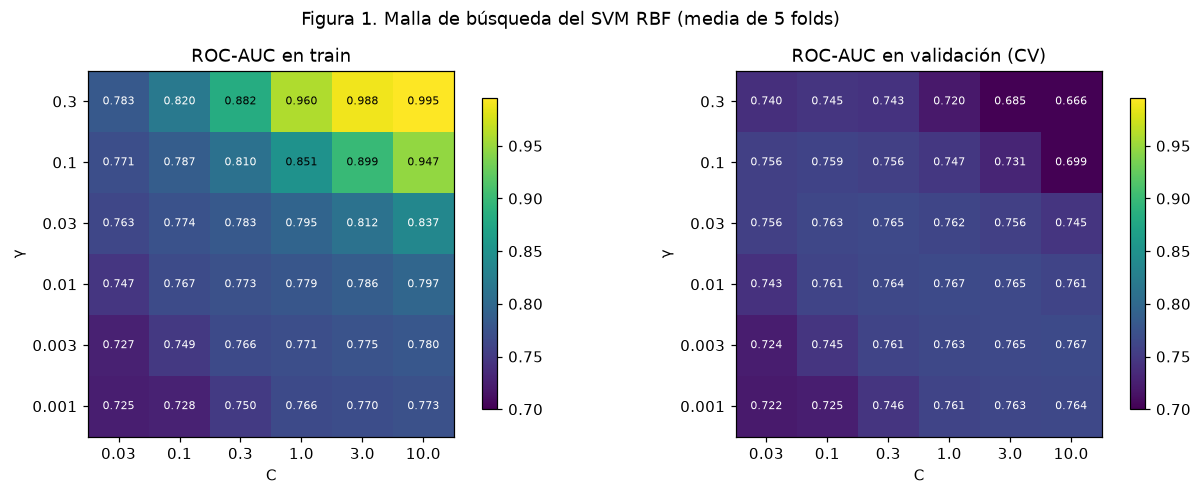

In [7]:
t0 = time.time()
malla_rbf = {"modelo__C": [0.03, 0.1, 0.3, 1, 3, 10],
             "modelo__gamma": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]}
grid_rbf = GridSearchCV(
    construir_pipeline(SVC(kernel="rbf", class_weight="balanced")),
    malla_rbf, cv=cv, scoring="roc_auc", n_jobs=-1, return_train_score=True,
).fit(X_train, y_train)

mejor_C = grid_rbf.best_params_["modelo__C"]
mejor_gamma = grid_rbf.best_params_["modelo__gamma"]
print(f"Tiempo: {time.time() - t0:.1f} s")
print(f"Mejor C: {mejor_C} | mejor γ: {mejor_gamma} | ROC-AUC CV: {grid_rbf.best_score_:.3f} "
      f"± {grid_rbf.cv_results_['std_test_score'][grid_rbf.best_index_]:.3f}")

res_rbf = pd.DataFrame(grid_rbf.cv_results_)
mapa_cv = res_rbf.pivot(index="param_modelo__gamma", columns="param_modelo__C", values="mean_test_score")
mapa_tr = res_rbf.pivot(index="param_modelo__gamma", columns="param_modelo__C", values="mean_train_score")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, mapa, titulo in [(axes[0], mapa_tr, "ROC-AUC en train"), (axes[1], mapa_cv, "ROC-AUC en validación (CV)")]:
    im = ax.imshow(mapa.to_numpy(), cmap="viridis", origin="lower", vmin=0.70, vmax=max(0.90, mapa_tr.to_numpy().max()))
    ax.set_xticks(range(mapa.shape[1])); ax.set_xticklabels(mapa.columns)
    ax.set_yticks(range(mapa.shape[0])); ax.set_yticklabels(mapa.index)
    ax.set_xlabel("C"); ax.set_ylabel("γ"); ax.set_title(titulo)
    for i in range(mapa.shape[0]):
        for j in range(mapa.shape[1]):
            valor = mapa.iloc[i, j]
            ax.text(j, i, f"{valor:.3f}", ha="center", va="center", fontsize=7.5,
                    color="black" if valor > 0.85 else "white")
    fig.colorbar(im, ax=ax, shrink=0.85)
fig.suptitle("Figura 1. Malla de búsqueda del SVM RBF (media de 5 folds)")
fig.tight_layout()
plt.show()

**Lectura de la Figura 1.** El mejor par es `C = 1` y `γ = 0.01` (ROC-AUC de
validación 0.767 ± 0.015), pero lo importante es que no es un pico aislado:
toda la región con `C` entre 0.3 y 10 y `γ` entre 0.003 y 0.03 queda entre
0.761 y 0.767, dentro de la variabilidad entre folds. Es decir, el modelo es
estable frente a los hiperparámetros en esa zona. Fuera de ella aparecen los
dos fallos clásicos:

- **Sobreajuste** (esquina superior derecha): con `γ = 0.3` y `C = 10` el AUC de
  train llega a 0.995, pero el de validación cae a 0.666. La frontera se
  vuelve tan flexible que memoriza a los clientes de entrenamiento.
- **Subajuste** (esquina inferior izquierda): con `C` y `γ` muy pequeños el
  modelo es casi constante y ambos AUC bajan a ~0.72.

### B.3 ¿Es el kernel gaussiano el mejor? Comparación de kernels

El artículo usa el kernel gaussiano (RBF), pero eso no garantiza que sea el
mejor en nuestros datos. Para comprobarlo, comparamos los cuatro kernels
estándar del SVM, cada uno con su propia malla de hiperparámetros ajustada por
validación cruzada:

| Kernel | $K(x, x')$ | Hiperparámetros |
|---|---|---|
| Lineal | $x^\top x'$ | `C` |
| Gaussiano (RBF) | $\exp(-\gamma \lVert x - x' \rVert^2)$ | `C`, `γ` |
| Polinómico | $(\gamma\, x^\top x' + r)^d$ | `C`, grado $d$, $r$ (`coef0`) |
| Sigmoide | $\tanh(\gamma\, x^\top x' + r)$ | `C`, `γ`, $r$ (`coef0`) |

Todos usan los **mismos 5 folds**, así que podemos compararlos fold a fold. Para
decidir si una diferencia es real o ruido usamos la **prueba t pareada corregida
de Nadeau y Bengio**: la prueba t clásica subestima la varianza porque los
folds comparten gran parte de los datos de entrenamiento, y la corrección
multiplica la varianza por $(1/k + n_{test}/n_{train})$. Hacemos la comparación
en las dos bases: German Credit (el escenario del artículo) y la simulada.

In [8]:
MALLAS_KERNEL = {
    "Lineal": {"modelo__kernel": ["linear"], "modelo__C": [0.003, 0.01, 0.03, 0.1, 0.3, 1]},
    "Gaussiano (RBF)": {"modelo__kernel": ["rbf"], "modelo__C": [0.03, 0.1, 0.3, 1, 3, 10],
                        "modelo__gamma": [0.001, 0.003, 0.01, 0.03, 0.1, 0.3]},
    "Polinómico": {"modelo__kernel": ["poly"], "modelo__C": [0.01, 0.1, 1],
                   "modelo__degree": [2, 3], "modelo__gamma": ["scale"], "modelo__coef0": [0, 1]},
    "Sigmoide": {"modelo__kernel": ["sigmoid"], "modelo__C": [0.01, 0.1, 1],
                 "modelo__gamma": [0.001, 0.01, 0.1], "modelo__coef0": [-1, 0, 1]},
}


def comparar_kernels(construir, X, y, n_train):
    # Ajusta cada kernel con su malla y devuelve el resumen y los puntajes por fold
    resumen, folds = {}, {}
    for nombre, malla in MALLAS_KERNEL.items():
        t0 = time.time()
        g = GridSearchCV(construir(SVC(class_weight="balanced")), malla,
                         cv=cv, scoring="roc_auc", n_jobs=-1).fit(X, y)
        i = g.best_index_
        folds[nombre] = np.array([g.cv_results_[f"split{k}_test_score"][i] for k in range(cv.n_splits)])
        params = {k.replace("modelo__", ""): v for k, v in g.best_params_.items() if k != "modelo__kernel"}
        resumen[nombre] = {"ROC-AUC CV (media)": folds[nombre].mean(),
                           "ROC-AUC CV (desv.)": folds[nombre].std(ddof=1),
                           "Mejores hiperparámetros": ", ".join(f"{k}={v}" for k, v in params.items()),
                           "Tiempo (s)": round(time.time() - t0, 1)}
    resumen = pd.DataFrame(resumen).T

    # Prueba t pareada corregida (Nadeau y Bengio, 2003) frente al kernel gaussiano
    ref = folds["Gaussiano (RBF)"]
    for nombre in folds:
        resumen.loc[nombre, "Diferencia vs. RBF"] = ref.mean() - folds[nombre].mean()
        resumen.loc[nombre, "p-valor (corregido)"] = (
            np.nan if nombre == "Gaussiano (RBF)" else p_valor_corregido(ref, folds[nombre], n_train, k=cv.n_splits))
    return resumen.sort_values("ROC-AUC CV (media)", ascending=False), folds


kernels_german, folds_german = comparar_kernels(pipeline_german, Xde_tr, yde_tr, len(Xde_tr))
kernels_sim, folds_sim = comparar_kernels(construir_pipeline, X_train, y_train, len(X_train))

print("German Credit (escenario del artículo):")
display(kernels_german.round(4))
print("Base simulada colombiana:")
display(kernels_sim.round(4))

German Credit (escenario del artículo):


,ROC-AUC CV (media),ROC-AUC CV (desv.),Mejores hiperparámetros,Tiempo (s),Diferencia vs. RBF,p-valor (corregido)
Gaussiano (RBF),0.790179,0.044893,"C=0.3, gamma=0.03",6.8,0.0000,NaN
Polinómico,0.789695,0.047868,"C=0.1, coef0=1, degree=2, gamma=scale",2.0,0.0005,0.9317
Sigmoide,0.787612,0.047664,"C=0.1, coef0=-1, gamma=0.1",4.6,0.0026,0.2697
Lineal,0.783222,0.047493,C=0.01,1.2,0.0070,0.4334


Base simulada colombiana:


,ROC-AUC CV (media),ROC-AUC CV (desv.),Mejores hiperparámetros,Tiempo (s),Diferencia vs. RBF,p-valor (corregido)
Gaussiano (RBF),0.766691,0.016997,"C=1, gamma=0.01",116.9,0.0000,NaN
Lineal,0.76422,0.017667,C=0.3,17.3,0.0025,0.1009
Sigmoide,0.763854,0.014914,"C=1, coef0=-1, gamma=0.01",84.6,0.0028,0.1557
Polinómico,0.763836,0.015568,"C=0.01, coef0=1, degree=2, gamma=scale",34.3,0.0029,0.2569


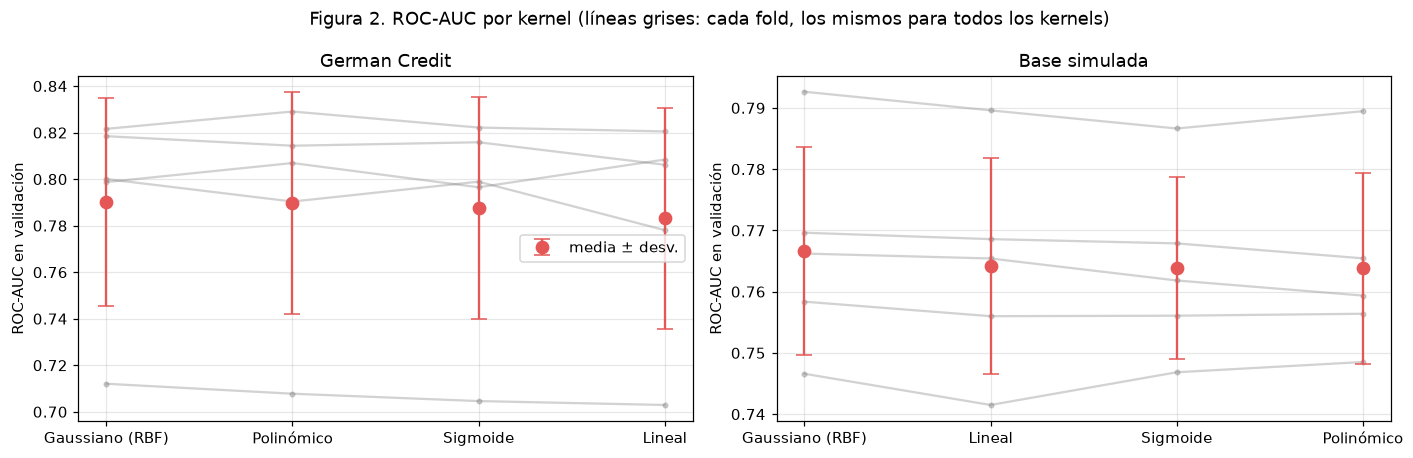

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (titulo, folds) in zip(axes, [("German Credit", folds_german), ("Base simulada", folds_sim)]):
    orden = sorted(folds, key=lambda n: folds[n].mean(), reverse=True)
    for k in range(cv.n_splits):
        ax.plot(orden, [folds[n][k] for n in orden], color="gray", alpha=0.35, marker="o", markersize=3)
    ax.errorbar(orden, [folds[n].mean() for n in orden], yerr=[folds[n].std(ddof=1) for n in orden],
                fmt="o", color="#E45756", capsize=5, markersize=8, label="media ± desv.")
    ax.set_title(titulo)
    ax.set_ylabel("ROC-AUC en validación")
    ax.grid(alpha=0.3)
axes[0].legend()
fig.suptitle("Figura 2. ROC-AUC por kernel (líneas grises: cada fold, los mismos para todos los kernels)")
fig.tight_layout()
plt.show()

**Lectura: ¿es el kernel gaussiano el mejor?** Nominalmente sí: el gaussiano
obtiene el mayor ROC-AUC de validación en las dos bases. Pero la ventaja es
mínima y **no es estadísticamente significativa**:

- En el **German Credit**, el gaussiano (0.790) supera al polinómico por 0.0005,
  al sigmoide por 0.003 y al lineal por 0.007, con p-valores corregidos entre
  0.27 y 0.93.
- En la **base simulada**, el gaussiano (0.767) supera a los otros tres por
  0.0025 a 0.0029, con p-valores entre 0.10 y 0.26.

La Figura 2 muestra por qué: las líneas grises (cada fold) son casi paralelas,
así que la diferencia entre folds (qué clientes caen en validación) pesa mucho
más que la diferencia entre kernels. Además, los hiperparámetros elegidos
apuntan a fronteras casi lineales: `γ` pequeño en el gaussiano y en el
sigmoide, y grado 2 con `C` muy bajo en el polinómico.

En la base simulada esto es lo esperable, porque el riesgo se generó con un
puntaje aditivo (lineal en el logit) cuya única no linealidad es una forma en U
leve de la edad: no hay estructura no lineal que un kernel más flexible pueda
aprovechar. Que en el German Credit pase algo parecido indica que en crédito
de consumo buena parte de la señal es aproximadamente lineal en las variables
codificadas. **Conclusión:** mantenemos el kernel gaussiano como la
reproducción del método del artículo, pero reportamos que el lineal rinde
estadísticamente igual y es más simple e interpretable, algo que pesará en la
selección del modelo final.

### B.4 Curvas de validación de `C` y `γ`

La malla muestra el promedio de validación, pero para ver el sobreajuste hay que
comparar train contra validación a lo largo de cada hiperparámetro. Trazamos
una curva para `C` (con `γ` fijo en su mejor valor) y otra para `γ` (con `C`
fijo en su mejor valor), con la banda de ± 1 desviación estándar entre folds, y
añadimos la curva de `C` del SVM lineal.

Tiempo: 112.0 s


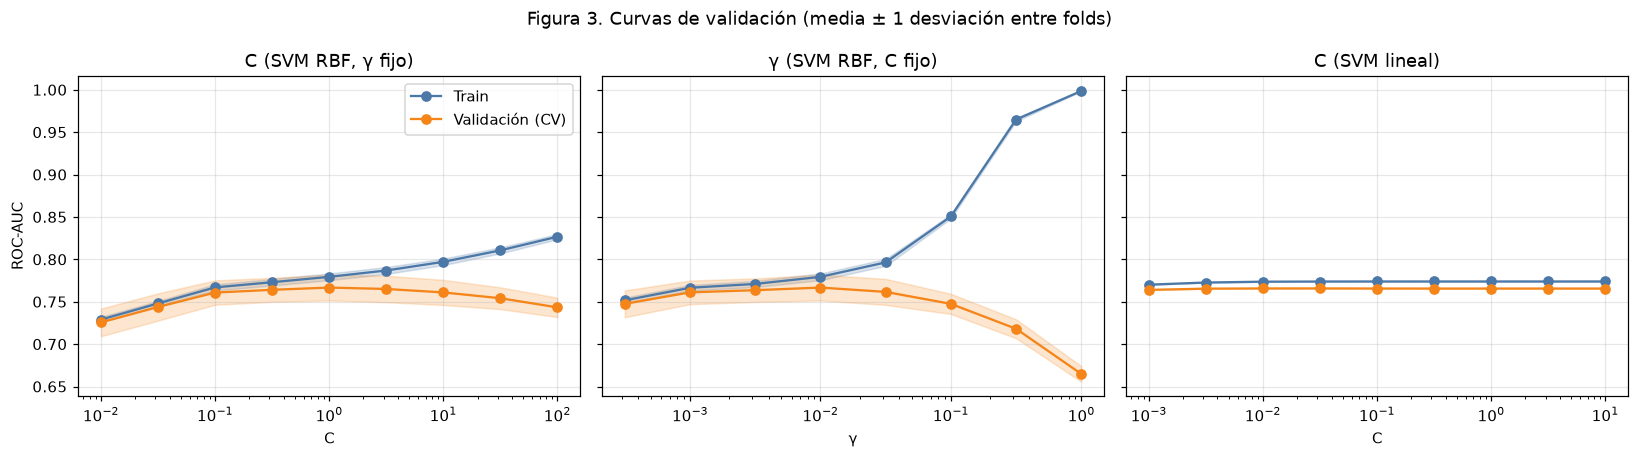

In [10]:
t0 = time.time()
rango_C = np.logspace(-2, 2, 9)
rango_gamma = np.logspace(-3.5, 0, 8)
rango_C_lineal = np.logspace(-3, 1, 9)

pipe_rbf = construir_pipeline(SVC(kernel="rbf", class_weight="balanced", C=mejor_C, gamma=mejor_gamma))
curvas = {
    "C (SVM RBF, γ fijo)": (rango_C, *validation_curve(
        pipe_rbf, X_train, y_train, param_name="modelo__C", param_range=rango_C,
        cv=cv, scoring="roc_auc", n_jobs=-1)),
    "γ (SVM RBF, C fijo)": (rango_gamma, *validation_curve(
        pipe_rbf, X_train, y_train, param_name="modelo__gamma", param_range=rango_gamma,
        cv=cv, scoring="roc_auc", n_jobs=-1)),
    "C (SVM lineal)": (rango_C_lineal, grid_lineal.cv_results_["mean_train_score"][:, None],
                       grid_lineal.cv_results_["mean_test_score"][:, None]),
}
print(f"Tiempo: {time.time() - t0:.1f} s")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (titulo, (rango, tr, va)) in zip(axes, curvas.items()):
    for scores, etiqueta, color in [(tr, "Train", "#4C78A8"), (va, "Validación (CV)", "#F58518")]:
        media, desv = scores.mean(axis=1), scores.std(axis=1)
        ax.plot(rango, media, marker="o", color=color, label=etiqueta)
        ax.fill_between(rango, media - desv, media + desv, color=color, alpha=0.2)
    ax.set_xscale("log")
    ax.set_title(titulo)
    ax.set_xlabel(titulo.split(" ")[0])
    ax.grid(alpha=0.3)
axes[0].set_ylabel("ROC-AUC")
axes[0].legend()
fig.suptitle("Figura 3. Curvas de validación (media ± 1 desviación entre folds)")
fig.tight_layout()
plt.show()

**Lectura de la Figura 3.**

- **`C` en el SVM RBF:** con `C < 0.1` el modelo subajusta (train y validación
  bajos y juntos). A partir de `C ≈ 1` la curva de train sigue subiendo, pero la
  de validación empieza a bajar (de 0.767 a 0.745 en `C = 100`): la brecha que se
  abre es el sobreajuste. El óptimo está en el punto donde la validación toca
  su máximo antes de que la brecha crezca.
- **`γ` en el SVM RBF:** es el hiperparámetro más sensible. Hasta `γ ≈ 0.03` train
  y validación van juntos; desde ahí train se dispara hacia 1.0 y validación se
  desploma hasta 0.665 en `γ = 1`. Un `γ` grande hace que cada cliente solo
  "vea" a sus vecinos inmediatos.
- **`C` en el SVM lineal:** la curva es plana para `C ≥ 0.003`, con una brecha
  train-validación de apenas 0.008. El modelo lineal casi no puede sobreajustar
  con 32 columnas y 4.160 registros por fold, y por eso es tan estable.

Las bandas de ± 1 desviación (≈ 0.015) son más anchas que las diferencias
entre valores cercanos al óptimo, lo que confirma que cualquier valor de la
meseta es una elección razonable.

### B.5 Fronteras de decisión en 2D

Una frontera de decisión solo se puede dibujar en dos dimensiones, así que para
visualizarla entrenamos SVM **solo con dos variables**: plazo y monto del
crédito, ya imputadas y escaladas con el mismo preprocesamiento. Son las dos
numéricas que más pesan en el riesgo y están correlacionadas entre sí (0.60).
Este modelo es ilustrativo: con dos variables el poder predictivo es mucho
menor que con las once, pero permite ver cómo cambia la forma de la frontera
entre el kernel lineal y el RBF, y cómo `γ` controla su flexibilidad.

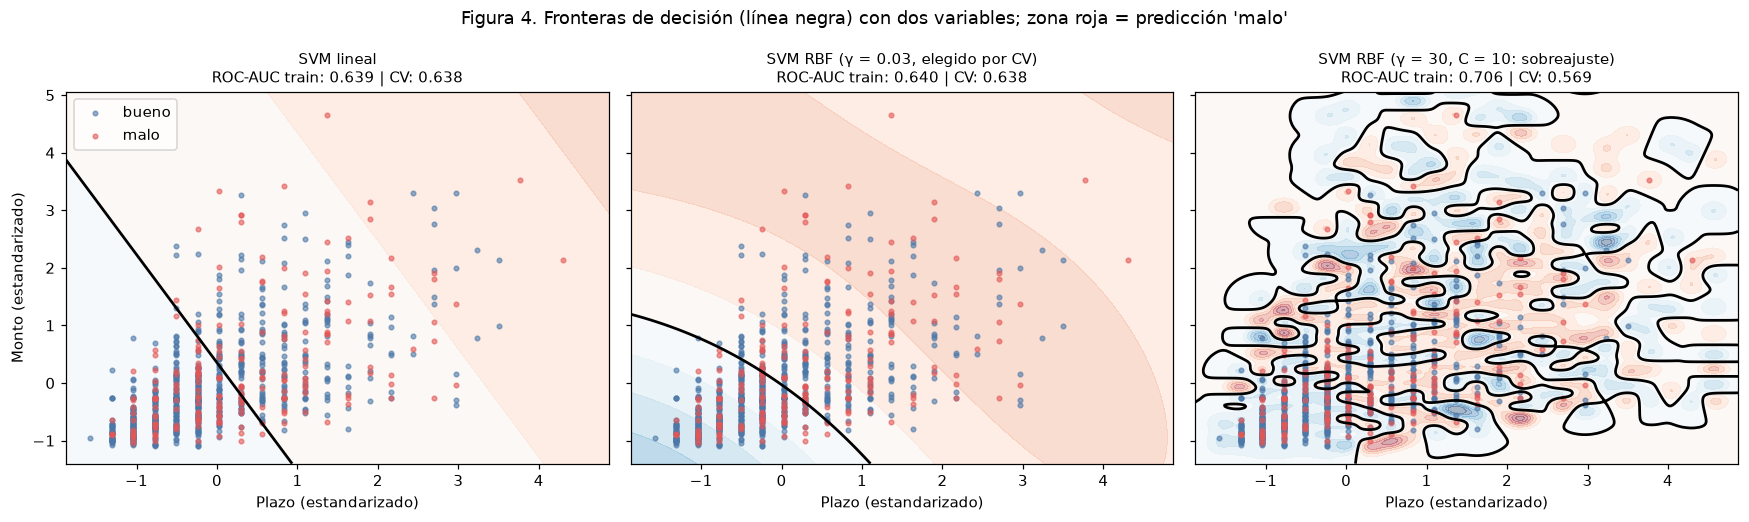

In [11]:
prep = construir_pipeline(LinearSVC())[:2].fit(X_train)       # imputación + escalamiento
X2_train = prep.transform(X_train)[["plazo_meses", "monto_credito_cop"]].to_numpy()

# γ se vuelve a elegir por CV: el valor óptimo con 32 columnas no es el mismo que con 2
grid_2d = GridSearchCV(SVC(kernel="rbf", class_weight="balanced", C=1),
                       {"gamma": [0.03, 0.1, 0.3, 1, 3]}, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_2d.fit(X2_train, y_train)
gamma_2d = grid_2d.best_params_["gamma"]

modelos_2d = {
    "SVM lineal": LinearSVC(class_weight="balanced", C=1, max_iter=50_000, random_state=SEED),
    f"SVM RBF (γ = {gamma_2d:g}, elegido por CV)": SVC(kernel="rbf", class_weight="balanced", C=1, gamma=gamma_2d),
    "SVM RBF (γ = 30, C = 10: sobreajuste)": SVC(kernel="rbf", class_weight="balanced", C=10, gamma=30),
}
x_min, x_max = X2_train[:, 0].min() - 0.3, X2_train[:, 0].max() + 0.3
y_min, y_max = X2_train[:, 1].min() - 0.3, np.quantile(X2_train[:, 1], 0.995) + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
rng_plot = np.random.default_rng(SEED)
muestra = rng_plot.choice(len(X2_train), size=900, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, (nombre, modelo) in zip(axes, modelos_2d.items()):
    auc_cv = cross_val_score(modelo, X2_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    modelo.fit(X2_train, y_train)
    auc_tr = roc_auc_score(y_train, modelo.decision_function(X2_train))
    zz = modelo.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=np.linspace(-3, 3, 13), cmap="RdBu_r", alpha=0.35, extend="both")
    ax.contour(xx, yy, zz, levels=[0], colors="black", linewidths=1.8)
    for clase, color, etiqueta in [(0, "#4C78A8", "bueno"), (1, "#E45756", "malo")]:
        m = muestra[y_train[muestra] == clase]
        ax.scatter(X2_train[m, 0], X2_train[m, 1], s=9, color=color, alpha=0.6, label=etiqueta)
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
    ax.set_title(f"{nombre}\nROC-AUC train: {auc_tr:.3f} | CV: {auc_cv:.3f}", fontsize=10)
    ax.set_xlabel("Plazo (estandarizado)")
axes[0].set_ylabel("Monto (estandarizado)")
axes[0].legend(loc="upper left")
fig.suptitle("Figura 4. Fronteras de decisión (línea negra) con dos variables; zona roja = predicción 'malo'")
fig.tight_layout()
plt.show()

**Lectura de la Figura 4.** Con solo plazo y monto, la frontera lineal y la del
RBF con `γ` elegido por validación cruzada (0.03) son casi iguales: el RBF apenas
la curva, y ambas tienen el mismo ROC-AUC de validación (0.638). Las dos dicen
lo mismo: los créditos más largos y más grandes (arriba a la derecha) caen en
la zona de "malo". Que el RBF no gane nada al curvar la frontera es la versión
visual de la comparación de kernels de la Sección B.3.

El tercer panel muestra qué pasa con `γ = 30` y `C = 10`: la frontera se
fragmenta en islas alrededor de clientes individuales. El AUC de train sube a
0.706, pero el de validación cae a 0.569, casi azar. Es la imagen del
sobreajuste que las curvas de la Figura 3 muestran en números. El AUC con dos
variables (~0.64) es mucho menor que con las once (~0.77) porque las variables
más informativas, como el historial de pago y el saldo en cuenta, son
categóricas y no entran en este gráfico.

### B.6 Evaluación en test y comparación con la línea base

Con los hiperparámetros elegidos por validación cruzada, elegimos el umbral de
decisión de cada modelo minimizando el costo 5:1 sobre sus predicciones de
validación cruzada en train, y solo entonces evaluamos una vez en test. Como
referencia incluimos la regresión logística del notebook 03 (misma partición,
mismo `Pipeline`, mismo tratamiento del umbral).

Además, como los datos son simulados, podemos calcular el **techo teórico** de
esta base: la probabilidad $P(\text{malo} \mid x)$ que tendría un modelo
perfecto que conociera exactamente la estructura generadora (los pesos del
puntaje latente), pero no el ruido idiosincrático, que por definición no es
observable. Ningún modelo entrenado con estas variables puede ordenar a los
clientes mejor que esa probabilidad. Su ROC-AUC en test es el máximo
alcanzable, y la regla de Bayes (clasificar como "malo" si $p > 1/6$, el umbral
óptimo para una matriz 5:1) da el costo mínimo esperado. La única ventaja que
le damos a este techo es que usa las variables sin faltantes ni ruido de
medición.

In [12]:
modelos_finales = {
    "Regresión logística (línea base)": construir_pipeline(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    "SVM lineal": grid_lineal.best_estimator_,
    "SVM RBF": grid_rbf.best_estimator_,
}
for nombre, etiqueta in [("Polinómico", "SVM polinómico"), ("Sigmoide", "SVM sigmoide")]:
    params = dict(MALLAS_KERNEL[nombre])
    mejores = {}
    for par in kernels_sim.loc[nombre, "Mejores hiperparámetros"].split(", "):
        clave, valor = par.split("=")
        mejores[clave] = valor if valor == "scale" else float(valor)
    if "degree" in mejores:
        mejores["degree"] = int(mejores["degree"])
    modelos_finales[etiqueta] = construir_pipeline(
        SVC(kernel=params["modelo__kernel"][0], class_weight="balanced", **mejores))

filas, umbrales = {}, {}
for nombre, modelo in modelos_finales.items():
    metodo = "decision_function"
    punt_cv = cross_val_predict(modelo, X_train, y_train, cv=cv, method=metodo, n_jobs=-1)
    umbrales[nombre] = umbral_costo_minimo(y_train, punt_cv)
    modelo.fit(X_train, y_train)
    punt_te = modelo.decision_function(X_test)
    filas[nombre] = metricas(y_test, punt_te, umbrales[nombre])
    filas[nombre]["ROC-AUC CV (media)"] = roc_auc_score(y_train, punt_cv)

# Techo teórico: P(malo | x) de la estructura generadora (los índices de la partición son id - 1)
_, p_obs = generar_base(seed=SEED, devolver_probabilidad=True)
techo = "Techo teórico: P(malo | x)"
filas[techo] = metricas(y_test, p_obs[X_test.index.to_numpy()], 1 / 6)
filas[techo]["ROC-AUC CV (media)"] = roc_auc_score(y_train, p_obs[X_train.index.to_numpy()])

resultados = pd.DataFrame(filas).T[["ROC-AUC CV (media)", "ROC-AUC", "Recall (malo)",
                                     "Precisión (malo)", "F1 (malo)", "Costo medio (5:1)"]]
resultados.round(3)

,ROC-AUC CV (media),ROC-AUC,Recall (malo),Precisión (malo),F1 (malo),Costo medio (5:1)
Regresión logística (línea base),0.765,0.773,0.856,0.339,0.485,0.537
SVM lineal,0.765,0.773,0.863,0.339,0.486,0.532
SVM RBF,0.766,0.776,0.808,0.355,0.494,0.545
SVM polinómico,0.764,0.775,0.825,0.351,0.493,0.538
SVM sigmoide,0.764,0.775,0.805,0.363,0.501,0.536
Techo teórico: P(malo | x),0.775,0.776,0.836,0.359,0.502,0.520


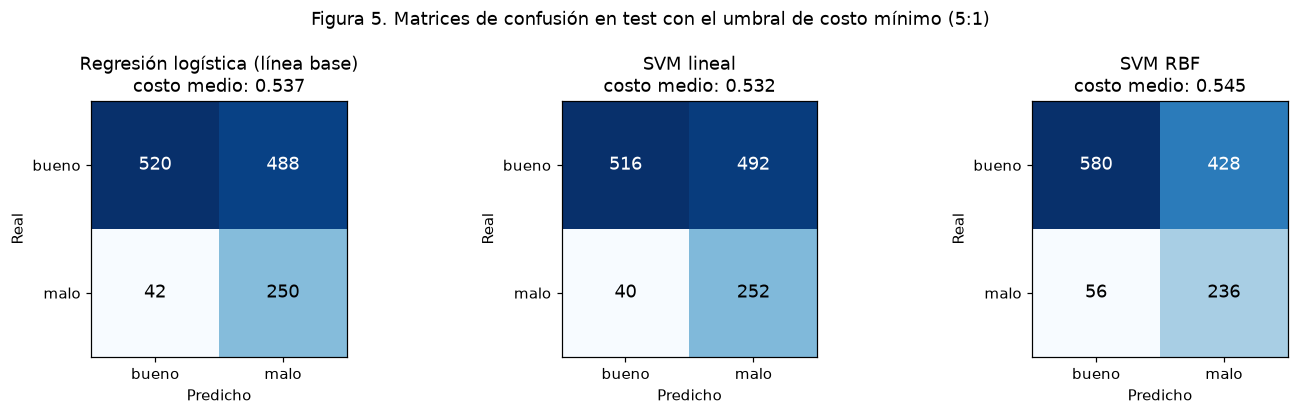

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, nombre in zip(axes, ["Regresión logística (línea base)", "SVM lineal", "SVM RBF"]):
    y_pred = (modelos_finales[nombre].decision_function(X_test) >= umbrales[nombre]).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["bueno", "malo"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["bueno", "malo"])
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(f"{nombre}\ncosto medio: {costo_medio(y_test, y_pred):.3f}")
fig.suptitle("Figura 5. Matrices de confusión en test con el umbral de costo mínimo (5:1)")
fig.tight_layout()
plt.show()

**Lectura.** Los cinco modelos quedan prácticamente empatados en test: ROC-AUC
entre 0.773 y 0.776 y costo medio entre 0.532 y 0.545. El SVM RBF tiene el
mayor AUC (0.776), el SVM lineal el menor costo (0.532), y ninguno supera
claramente a la regresión logística (0.773 y 0.537). La Figura 5 muestra que,
con el umbral de costo mínimo, los tres modelos detectan a más del 80% de los
clientes "malos" a cambio de rechazar a una parte de los "buenos", que es lo que
pide una matriz 5:1.

El techo teórico explica el empate. Un modelo que conociera exactamente la
estructura generadora obtendría un ROC-AUC de 0.776 en test y 0.775 en
validación, prácticamente lo mismo que los SVM. Es decir, **los modelos ya
extraen casi toda la señal disponible en estas variables**; lo que falta para
llegar a un AUC de 1 es el ruido idiosincrático, que por construcción no es
predecible. Este resultado tiene dos consecuencias para el proyecto:

1. En esta base, ningún modelo (SVM, Random Forest ni Boosting) puede superar
   por mucho a la regresión logística; las diferencias entre modelos estarán
   acotadas por construcción.
2. Es la cuantificación directa de la limitación de circularidad documentada
   en `docs/construccion_base_datos.md`: el desempeño mide qué tan bien se
   invierte la función generadora, no el poder predictivo en datos reales.

El costo medio de la regla de Bayes (0.520) muestra que el umbral elegido por
validación cruzada deja muy poco costo sobre la mesa (0.012 por cliente con el
SVM lineal).

### B.7 Coeficientes del SVM lineal

En un SVM lineal la función de decisión es $f(x) = w^\top x + b$, así que cada
coeficiente $w_j$ indica cuánto empuja la variable $j$ hacia "malo" (positivo) o
hacia "bueno" (negativo). Como todas las numéricas están estandarizadas, sus
coeficientes son comparables entre sí. En las categóricas one-hot, lo que tiene
sentido es la diferencia entre categorías de una misma variable, así que
centramos sus coeficientes dentro de cada variable (restamos la media de sus
categorías).

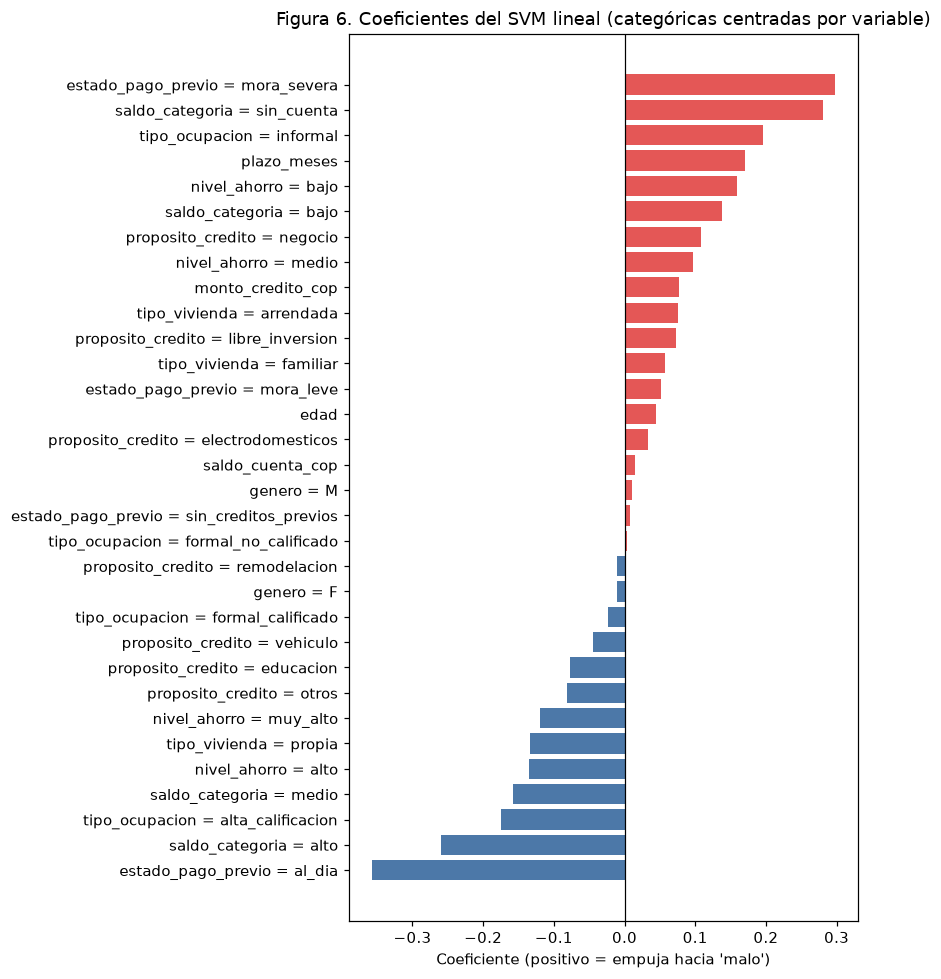

In [14]:
svm_lineal = grid_lineal.best_estimator_
nombres = svm_lineal[:-1].get_feature_names_out()
w = pd.Series(svm_lineal.named_steps["modelo"].coef_.ravel(), index=nombres)

filas = []
for nombre, coef in w.items():
    var = next((c for c in CAT_COLS if nombre.startswith(c + "_")), nombre)
    cat = nombre[len(var) + 1:] if var != nombre else ""
    filas.append({"variable": var, "categoría": cat, "coeficiente": coef})
coefs = pd.DataFrame(filas)
es_cat = coefs["variable"].isin(CAT_COLS)
coefs.loc[es_cat, "coeficiente"] -= coefs[es_cat].groupby("variable")["coeficiente"].transform("mean")
coefs["etiqueta"] = np.where(coefs["categoría"] == "", coefs["variable"],
                             coefs["variable"] + " = " + coefs["categoría"])
coefs = coefs.sort_values("coeficiente")

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(coefs["etiqueta"], coefs["coeficiente"],
        color=np.where(coefs["coeficiente"] > 0, "#E45756", "#4C78A8"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (positivo = empuja hacia 'malo')")
ax.set_title("Figura 6. Coeficientes del SVM lineal (categóricas centradas por variable)")
fig.tight_layout()
plt.show()

**Contraste con los pesos reales de la simulación.** Como construimos los datos,
sabemos con qué peso entra cada categoría en el puntaje de riesgo (constantes
`PESOS_CATEGORICOS` de `src/generar_datos_simulados.py`). Si el SVM lineal
aprende la estructura correcta, sus coeficientes centrados deberían ordenarse
igual que esos pesos (también centrados). Lo medimos con la correlación de
Spearman, que solo compara el orden.

Correlación de Spearman (pesos reales vs. coeficientes SVM): 0.939 (p = 1.3e-12)
Categorías con el signo correcto: 24 de 26
Categorías con signo distinto:
          variable            categoría  peso_real  coeficiente
estado_pago_previo sin_creditos_previos     -0.200        0.008
 proposito_credito                otros      0.079       -0.081

Coeficientes de las numéricas (estandarizadas):
variable
saldo_cuenta_cop     0.014
edad                 0.045
monto_credito_cop    0.077
plazo_meses          0.171


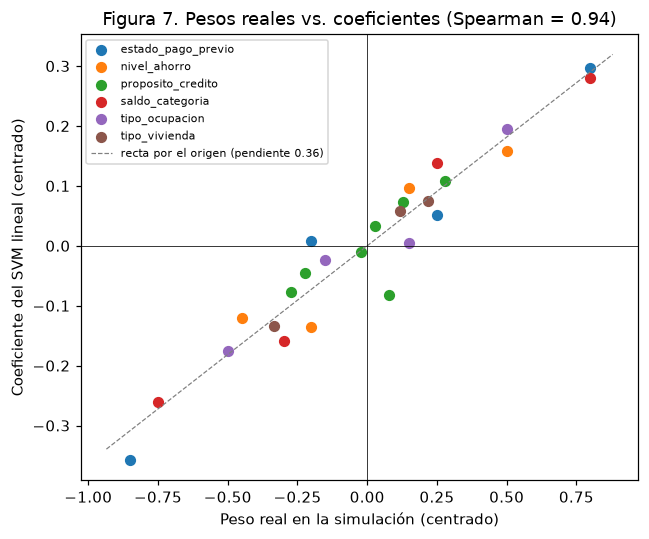

In [15]:
pesos = pd.DataFrame([
    {"variable": var, "categoría": cat, "peso_real": peso}
    for var, mapa in PESOS_CATEGORICOS.items() for cat, peso in mapa.items()
])
pesos["peso_real"] -= pesos.groupby("variable")["peso_real"].transform("mean")
contraste = pesos.merge(coefs[["variable", "categoría", "coeficiente"]], on=["variable", "categoría"])

rho, pval = spearmanr(contraste["peso_real"], contraste["coeficiente"])
signos = (np.sign(contraste["peso_real"]) == np.sign(contraste["coeficiente"])) | (contraste["peso_real"].abs() < 1e-9)
print(f"Correlación de Spearman (pesos reales vs. coeficientes SVM): {rho:.3f} (p = {pval:.1e})")
print(f"Categorías con el signo correcto: {signos.sum()} de {len(contraste)}")
print("Categorías con signo distinto:")
print(contraste.loc[~signos, ["variable", "categoría", "peso_real", "coeficiente"]].round(3).to_string(index=False))

numericas = coefs.loc[~coefs["variable"].isin(CAT_COLS)].set_index("variable")["coeficiente"]
print("\nCoeficientes de las numéricas (estandarizadas):")
print(numericas.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 5))
for var, grupo in contraste.groupby("variable"):
    ax.scatter(grupo["peso_real"], grupo["coeficiente"], label=var, s=40)
# La pérdida bisagra del SVM no está en escala logit: se ajusta una recta por el
# origen para mostrar la proporcionalidad, no la igualdad
pendiente = (contraste["peso_real"] @ contraste["coeficiente"]) / (contraste["peso_real"] @ contraste["peso_real"])
xs = np.linspace(contraste["peso_real"].min() * 1.1, contraste["peso_real"].max() * 1.1, 10)
ax.plot(xs, pendiente * xs, "--", color="gray", linewidth=0.8,
        label=f"recta por el origen (pendiente {pendiente:.2f})")
ax.axhline(0, color="black", linewidth=0.5); ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Peso real en la simulación (centrado)")
ax.set_ylabel("Coeficiente del SVM lineal (centrado)")
ax.set_title(f"Figura 7. Pesos reales vs. coeficientes (Spearman = {rho:.2f})")
ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

**Lectura.** El SVM lineal recupera la estructura con la que se generaron los
datos: la correlación de Spearman entre sus coeficientes y los pesos reales es
0.94, y 24 de las 26 categorías tienen el signo correcto. Las dos excepciones
son categorías pequeñas con pesos cercanos a cero: `sin_creditos_previos` (9%
de los clientes, coeficiente 0.008) y `otros` en propósito (7% de los
clientes, peso real 0.08). Con tan pocos clientes, sus coeficientes se estiman
con mucho ruido. Las variables más influyentes son las esperadas: historial de
pago (al día frente a mora severa), saldo en cuenta (sin cuenta frente a saldo
alto) y ocupación informal.

Los coeficientes están comprimidos respecto a los pesos reales (pendiente
menor que 1 en la Figura 7) porque la pérdida bisagra del SVM y la
regularización no están en la escala logit con que se generaron los datos; lo
que importa es el orden, no el nivel. En las numéricas, el plazo (0.17) pesa más
que el monto (0.08), aunque en la simulación el monto tiene un peso algo mayor:
como están correlacionados (0.60), el modelo reparte entre ambos el efecto
común. El saldo en COP casi no aporta (0.014), lo cual es correcto, porque en la
simulación el saldo solo afecta al riesgo a través de su categoría. Y la edad
sale con coeficiente positivo aunque su término lineal real es negativo: la
forma en U, combinada con la asimetría de la edad (más jóvenes que mayores),
hace que la mejor aproximación lineal tenga pendiente positiva.

**Contraste con las variables importantes del artículo.** Los autores
identifican como más importantes el saldo de la cuenta (`checking`), la
duración (`duration`), el estado de pago del crédito anterior
(`credit_history`), el propósito (`purpose`) y el monto (`credit_amount`).
Para comparar, calculamos la importancia de cada variable original en nuestro
SVM lineal sobre el German Credit (Parte A.2). Como una variable categórica
tiene varios coeficientes, uno por categoría, medimos su importancia como el
rango de sus coeficientes (cuánto cambia la decisión al pasar de la categoría
más favorable a la más desfavorable); para una numérica estandarizada usamos
$2|w|$ (el cambio al pasar de una desviación por debajo a una por encima de la
media), que es una escala comparable.

In [16]:
svm_de = grid_de_lineal.best_estimator_
w_de = pd.Series(svm_de.named_steps["modelo"].coef_.ravel(),
                 index=svm_de.named_steps["prep"].get_feature_names_out())
variable_de = pd.Series([next((c for c in cat_de if n.startswith(c + "_")), n) for n in w_de.index],
                        index=w_de.index)

importancia = pd.Series({
    var: (w_de[variable_de == var].max() - w_de[variable_de == var].min()) if var in cat_de
    else 2 * abs(w_de[var])
    for var in variable_de.unique()
}).sort_values(ascending=False)

ARTICULO_IMPORTANTES = ["checking", "duration", "credit_history", "purpose", "credit_amount"]
equivalencias = {
    "checking": "saldo_categoria", "credit_history": "estado_pago_previo",
    "savings": "nivel_ahorro", "purpose": "proposito_credito", "housing": "tipo_vivienda",
    "job": "tipo_ocupacion", "duration": "plazo_meses", "credit_amount": "monto_credito_cop",
    "age": "edad",
}
ranking = pd.DataFrame({
    "importancia": importancia.round(3),
    "puesto": np.arange(1, len(importancia) + 1),
    "importante según el artículo": ["Sí" if v in ARTICULO_IMPORTANTES else "" for v in importancia.index],
    "equivalente simulado": [equivalencias.get(v, "") for v in importancia.index],
})
puestos = ranking.loc[ARTICULO_IMPORTANTES, "puesto"]
print("Puesto de las 5 variables del artículo en nuestro ranking (de 20):", puestos.to_dict())
print(f"{(puestos <= 7).sum()} de las 5 están entre nuestras 7 más importantes.")
display(ranking)

print("Signo de los coeficientes de las categorías de checking y credit_history:")
print(w_de[variable_de.isin(["checking", "credit_history"])].round(3).to_string())

Puesto de las 5 variables del artículo en nuestro ranking (de 20): {'checking': 1, 'duration': 2, 'credit_history': 4, 'purpose': 7, 'credit_amount': 11}
4 de las 5 están entre nuestras 7 más importantes.


,importancia,puesto,importante según el artículo,equivalente simulado
checking,0.427,1,Sí,saldo_categoria
duration,0.241,2,Sí,plazo_meses
savings,0.228,3,,nivel_ahorro
credit_history,0.219,4,Sí,estado_pago_previo
employment_since,0.197,5,,
other_installment_plans,0.196,6,,
purpose,0.192,7,Sí,proposito_credito
installment_rate,0.185,8,,
property,0.158,9,,
personal_status_sex,0.150,10,,


Signo de los coeficientes de las categorías de checking y credit_history:
checking_A11          0.177
checking_A12          0.078
checking_A13         -0.003
checking_A14         -0.250
credit_history_A30    0.069
credit_history_A31    0.054
credit_history_A32    0.023
credit_history_A33    0.006
credit_history_A34   -0.149


**Lectura.** Nuestro SVM lineal coincide en buena medida con el artículo: el
**saldo de la cuenta es la variable más importante** y la **duración la
segunda**; el historial de crédito queda cuarto y el propósito séptimo. Cuatro
de las cinco variables que destacan los autores están entre nuestras siete más
importantes (de 20). La excepción es el monto (puesto 11): como está
correlacionado con la duración (0.62), buena parte de su efecto lo absorbe la
duración en el modelo lineal. Entre nuestras más importantes aparecen además
el ahorro (tercero) y la antigüedad laboral (quinto), que el resumen del
artículo no menciona.

La coincidencia está en la **importancia**, pero no en todos los **signos**:

- En `checking`, la categoría con el coeficiente más negativo es `A14` (sin cuenta
  corriente, −0.25), es decir, se asocia a *menor* riesgo, mientras que `A11`
  (saldo negativo) empuja hacia "malo" (+0.18).
- En `credit_history`, `A34` (cuenta crítica) también es negativa (−0.15),
  mientras que `A30` y `A31` (sin créditos o pagados a tiempo) son positivas.

Como el SVM lineal controla por las demás variables, estos signos no son solo
un efecto de confusión del cruce univariado. En la Primera entrega fijamos la
dirección "no tener cuenta aumenta el riesgo" a partir de nuestra lectura de
los coeficientes del artículo; nuestra estimación no la respalda en el German
Credit. Por eso, en la simulación la mantenemos como una **decisión explícita
de adaptación al contexto colombiano** (notebook 01, Sección 1), y no como un
resultado del dataset original. En cambio, el ahorro bajo (`savings_A61`) y la
duración empujan hacia "malo", igual que en la simulación.

## Justificación de la adaptación

**Qué se respetó del artículo.**

- **El método:** SVM con kernel gaussiano (RBF) como modelo principal y SVM
  lineal como versión interpretable, con la importancia de cada variable leída
  de sus coeficientes; y la regresión logística como modelo de comparación.
- **El problema:** clasificación binaria del riesgo crediticio (bueno/malo) a
  partir de información sociodemográfica, patrimonial, del crédito solicitado y
  del historial de pago, con la misma estructura de variables del German Credit.
- **El preprocesamiento que exige el kernel:** escalamiento de las numéricas y
  codificación de las categóricas, porque el RBF depende de distancias.
- **El ajuste de hiperparámetros:** `C` y `γ` elegidos por validación cruzada
  sobre una malla logarítmica.
- **Las métricas del artículo:** accuracy, precisión, recall, F1 y ROC-AUC.
- **La verificación en el escenario original:** antes de adaptar, reprodujimos
  el método sobre el German Credit con la configuración del artículo (Parte
  A.1) y obtuvimos la misma accuracy del SVM (75.5% frente a 75%) y las mismas
  variables más importantes.

**Qué se cambió para el contexto colombiano, y por qué.**

| Cambio | Motivo |
|---|---|
| Datos: base simulada de 6.500 clientes en COP, con variables de mercado colombiano (informalidad, arriendo, propósitos de consumo locales) | No hay microdatos crediticios públicos en Colombia (Ley 1266 de 2008) |
| Dirección de "sin cuenta" y "cuenta crítica" invertida respecto al German Credit | En Colombia se asume que no tener cuenta indica exclusión financiera; nuestro SVM lineal alemán da el signo contrario (Sección B.7) |
| 22.5% de "malo" en lugar de 30% | Desbalance más cercano a carteras de consumo colombianas, fijado en la Primera entrega |
| Faltantes (3%-5%) y ruido de medición, tratados con imputación dentro del `Pipeline` | Los datos reales de solicitudes llegan incompletos; el German Credit no tiene faltantes |
| ROC-AUC para elegir hiperparámetros (en vez de accuracy) y F1 y recall de "malo" para evaluar | Es la métrica principal definida en la Primera entrega; la accuracy premia predecir "bueno" y no refleja el costo de los errores (Parte A) |
| `class_weight="balanced"` y umbral de costo mínimo 5:1, ambos elegidos con validación cruzada en train | Un falso negativo cuesta más que un falso positivo; el pesado ganó a SMOTENC en el notebook 03 |
| Comparación de cuatro kernels con prueba t corregida | Comprobar con evidencia, y no por supuesto, que el kernel del artículo es el adecuado |
| Techo teórico `P(malo \| x)` | Solo es posible con datos simulados; cuantifica cuánto de la señal extraen los modelos |

Estas modificaciones cambian los datos y el procedimiento de validación, pero
no el propósito del método: construir un clasificador de riesgo con margen
máximo, capaz de capturar relaciones no lineales mediante el kernel y cuya
versión lineal permite interpretar qué variables pesan en la decisión.

## Conclusiones

1. **Reproducción del artículo:** sobre el German Credit, nuestro SVM RBF
   alcanza una accuracy de 75.5% en validación cruzada, igual al 75% reportado,
   y el SVM lineal identifica como más importantes el saldo de la cuenta y la
   duración, como los autores. En cambio, una regresión logística bien ajustada
   llega a 74.8% (no a 70%), así que la ventaja del SVM sobre la logística no se
   reproduce (diferencia de +0.8 puntos, p = 0.76).
2. **Ajuste de hiperparámetros:** en la base simulada, el mejor SVM RBF usa
   `C = 1` y `γ = 0.01` (ROC-AUC de validación 0.767 ± 0.015), dentro de una
   meseta estable. Las curvas de validación muestran que `γ` es el
   hiperparámetro más sensible: por encima de 0.03 el modelo sobreajusta
   rápidamente.
3. **Kernel:** el gaussiano es nominalmente el mejor en las dos bases, pero su
   ventaja sobre el lineal, el polinómico y el sigmoide (≤ 0.007 de ROC-AUC) no
   es estadísticamente significativa (p ≥ 0.10 con la prueba t corregida).
4. **Desempeño en la base colombiana:** en test, el SVM RBF (ROC-AUC 0.776; F1
   de "malo" 0.494) y el SVM lineal (costo medio 0.532) empatan con la regresión
   logística (ROC-AUC 0.773; F1 0.485; costo 0.537) y con el techo teórico de la
   base (ROC-AUC 0.776). Los modelos ya extraen casi toda la señal disponible,
   así que las diferencias entre modelos en esta base están acotadas por
   construcción.
5. **Interpretación:** los coeficientes del SVM lineal recuperan la estructura
   generadora de la simulación (Spearman 0.94; 24 de 26 signos correctos). El
   historial de pago, el saldo en cuenta y la informalidad laboral son las
   variables más influyentes.
6. **Adaptación:** en el German Credit, no tener cuenta corriente se asocia a
   menor riesgo incluso controlando por las demás variables. La dirección
   contraria en la simulación es una decisión de adaptación al contexto
   colombiano, y así se declara.

En conjunto, el SVM es un buen clasificador de riesgo, pero en ninguna de las
dos bases supera de forma significativa a una regresión logística bien
preparada. Para la selección del modelo final, el SVM lineal ofrece el mismo
desempeño que el RBF con mayor simplicidad e interpretabilidad; el RBF se
mantiene como la reproducción fiel del método del artículo.